# L0.1 — Install and test

**Level 0**

**Goal.** You have a Python environment that runs the library and its tests.

**Check at the end.** The test suite is green. You can say what the `examples` extra adds that the
core install does not have.

## 1. Install the library

OpenCDaRR is not on PyPI. Install it from your clone. Do these two commands in a terminal, in the
directory of the repository:

```bash
conda create -n opencdarr python=3.11 && conda activate opencdarr
```

```bash
pip install -e ".[examples]"
```

The `-e` flag makes an editable install. Your changes to the source code become active immediately.
You do not install the library again.

The `examples` extra adds three things that the core install does not have:

| Package | Purpose |
| --- | --- |
| `matplotlib` | Every figure in this course. |
| `ipykernel` | The Jupyter kernel that runs these notebooks. |
| `joblib` | The parallel backend that Level 6 needs. |

The core install stays small on purpose. It needs only `numpy` and `pyyaml`. The library imports
`matplotlib` and `joblib` only in the functions that use them.

## 2. Check the environment

The next cell prints what you have. Read each line. If a line shows an error, correct it before you
continue.

In [1]:
import sys
from pathlib import Path

import numpy as np

import opencdarr

REPO = Path.cwd().parents[1]          # this notebook is in examples/curriculum/

print(f"python        {sys.version.split()[0]}")
print(f"numpy         {np.__version__}")
print(f"opencdarr     {opencdarr.__version__}")
print(f"installed at  {Path(opencdarr.__file__).parent}")
print(f"repository    {REPO}")

try:
    import matplotlib
    print(f"matplotlib    {matplotlib.__version__}   (the examples extra is present)")
except ImportError:
    print("matplotlib    MISSING — install with: pip install -e '.[examples]'")

try:
    import joblib
    print(f"joblib        {joblib.__version__}   (Level 6 can run in parallel)")
except ImportError:
    print("joblib        missing — only Level 6 needs it")

python        3.11.7
numpy         1.26.4
opencdarr     0.0.0
installed at  /Users/mfrahman/Projects/OpenCDaRR/opencdarr
repository    /Users/mfrahman/Projects/OpenCDaRR
matplotlib    3.8.0   (the examples extra is present)
joblib        1.2.0   (Level 6 can run in parallel)


## 3. Run the test gate

`pytest` is the gate that must pass. The full suite has more than 570 tests and takes some minutes.
This cell runs two small files only: the smoke test and the public-API test. Run the full suite
once in your terminal after this notebook.

```bash
pytest
```

`mypy` and `ruff` also run in this repository. Both report findings today. Most of the findings are
in `scripts/` and in the example notebooks, which the project holds to speed and not to rigour. Do
not use them as a gate.

In [2]:
import subprocess

result = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "tests/test_smoke.py", "tests/test_public_api.py"],
    cwd=REPO, capture_output=True, text=True,
)
print(result.stdout.strip()[-600:])
print(f"\nexit code {result.returncode}   (0 means green)")

...............                                                          [100%]

exit code 0   (0 means green)


## 4. What the course builds

This figure is the destination. It shows one encounter between a multirotor and a fixed-wing. The
same encounter runs four times. Each panel adds one layer of reality.

![One crossing between a multirotor and a fixed-wing, resolved under four conditions](../../docs/img/overview.png)

| Panel | Layer | Result |
| --- | --- | --- |
| 1 | Perfect information | One run. The closest approach is 89 m. |
| 2 | GNSS and datalink noise | 200 runs. P(LoS) is 0.01 for each run. |
| 3 | A waypoint | The multirotor goes back to its mission after it avoids. |
| 4 | Wind | A steady 10 m/s. P(LoS) increases to 0.03 for each run. |

Level 1 makes each of these layers separately. Level 2 puts them together. Levels 3 to 8 measure
the result.

## 5. Your first encounter

Now fly two aircraft. A multirotor goes to the north. A fixed-wing starts in a conflict with it.

`create_conflict` puts the second aircraft where it must be for a conflict at a given time. You
give it the crossing angle (`dpsi`), the miss distance (`dcpa`), and the time to the loss of
separation (`tlos`). Level 2 examines this function in detail.

The first run has **no resolver**. Nothing avoids. This is the baseline.

conflict detected   True
separation lost     True
closest approach    0.0 m   (the protected zone is 50 m)


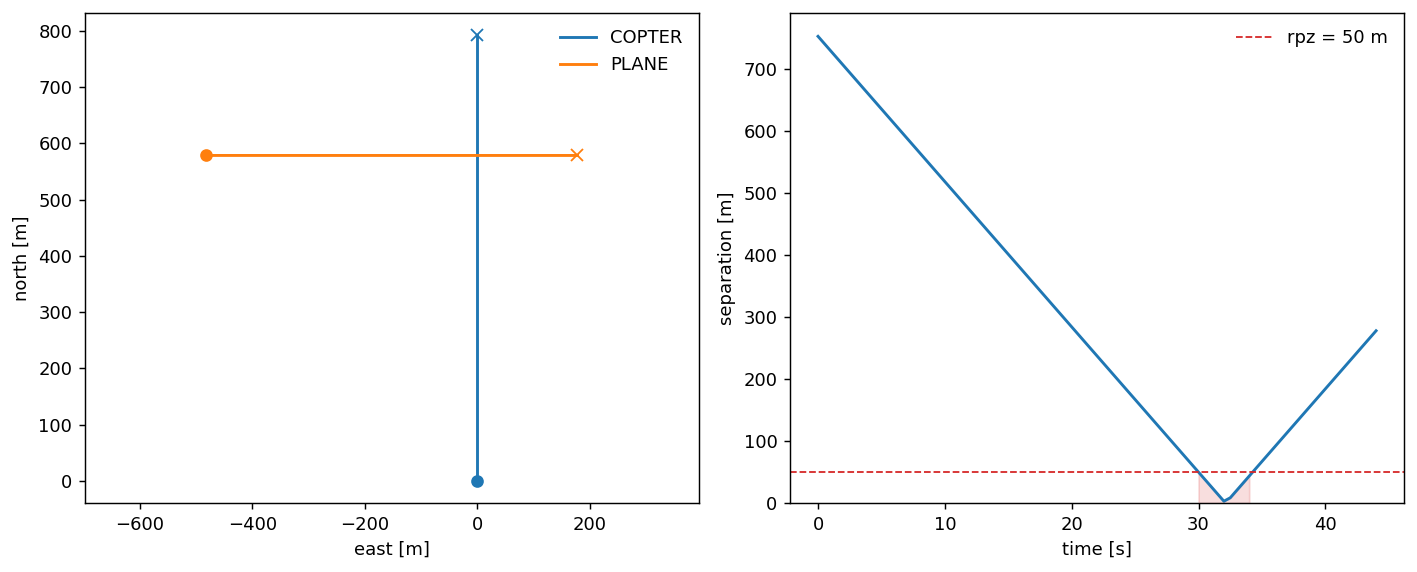

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False

from opencdarr import (
    M600,                # the speed and acceleration limits of a DJI M600
    MVP,                 # an avoidance algorithm
    SMALL_FIXEDWING,     # the limits of a small fixed-wing
    Agent,               # one aircraft: its state, plus what flies it
    AircraftState,
    PastCPA,             # decides when it is safe to stop the avoidance
    StateBased,          # decides whether a conflict exists
    create_conflict,     # puts an intruder into a conflict on purpose
    plot_pairwise,       # draws a recorded run
    run_fleet,           # flies one encounter to its end
)
from opencdarr.kinematics import FixedWing, Multirotor

RPZ = 50.0    # the radius of the protected zone [m]

copter = AircraftState(id="COPTER", lat=52.0, lon=4.0, trk=0.0, gs=18.0, yaw=0.0)
plane = create_conflict(copter, intr_id="PLANE", dpsi=90.0, dcpa=0.0,
                        tlos=30.0, rpz=RPZ, gs_intr=15.0)

agents = [
    Agent(copter, M600, Multirotor()),
    Agent(plane, SMALL_FIXEDWING, FixedWing()),
]

baseline = run_fleet(
    agents, rpz=RPZ, t_lookahead=20.0, dt=0.5,
    detector=StateBased(), resolver=None, recovery=None,
    record=True,          # keep every frame, so that you can plot it
)

print(f"conflict detected   {baseline.conflict}")
print(f"separation lost     {baseline.los}")
print(f"closest approach    {baseline.min_sep:.1f} m   (the protected zone is {RPZ:.0f} m)")

fig = plot_pairwise(baseline, rpz=RPZ)

`plot_pairwise(run, rpz=...)` draws a recorded run. It needs `record=True` on the run. It draws the
ground tracks on the left and the separation against the time on the right. A circle marks the
start of a track and a cross marks the end. Give `rpz=` to mark the protected zone.

To draw the run yourself, use `extract_tracks(run)` instead. It gives you plain arrays.

## 6. Add the separation logic

Now add two modules. `MVP` calculates an avoidance command. `PastCPA` decides when the aircraft can
go back to its plan. Nothing else changes.

conflict detected   True
separation lost     False
closest approach    92.5 m

                        baseline   MVP + PastCPA
separation lost             True           False
closest approach           0.0 m          92.5 m


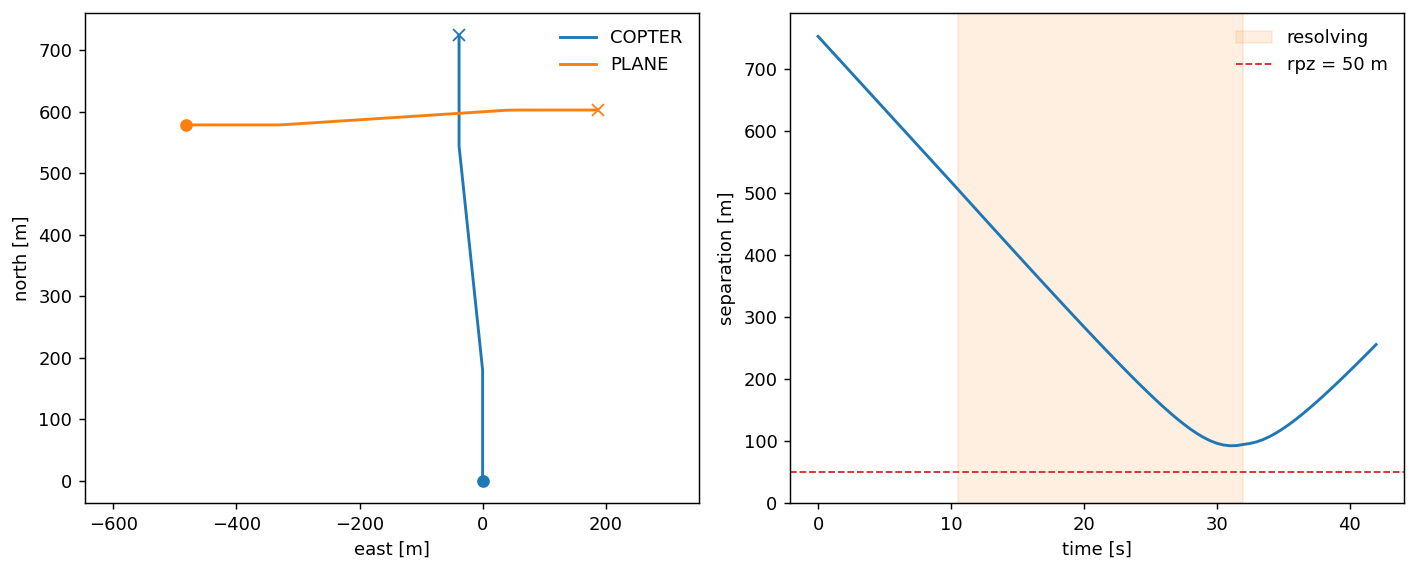

In [4]:
resolved = run_fleet(
    agents, rpz=RPZ, t_lookahead=20.0, dt=0.5,
    detector=StateBased(), resolver=MVP(), recovery=PastCPA(),
    record=True,
)

print(f"conflict detected   {resolved.conflict}")
print(f"separation lost     {resolved.los}")
print(f"closest approach    {resolved.min_sep:.1f} m")
print()
print(f"{'':<20}{'baseline':>12}{'MVP + PastCPA':>16}")
print(f"{'separation lost':<20}{str(baseline.los):>12}{str(resolved.los):>16}")
print(f"{'closest approach':<20}{baseline.min_sep:>10.1f} m{resolved.min_sep:>14.1f} m")

fig = plot_pairwise(resolved, rpz=RPZ)

The orange band on the right panel marks the time when an aircraft avoids.

You changed the result with two arguments. You did not edit the loop. Every module in this library
works this way: you build an object, and you give it to the runner.

## 7. Change one thing at a time

Go back to the cell above. Change one argument. Run it again. Record the closest approach each
time. This method — one change, one result — is the method of the whole course.

- Give `MVP(margin=1.5)` instead of `MVP()`. The margin makes the avoidance larger.
- Give `recovery=None`. The aircraft continues to avoid and never goes back to its plan.
- Change `t_lookahead` from 20 s to 60 s. The avoidance starts earlier.

## Check

Answer these before you continue:

1. The test suite is green. Is it green on your machine?
2. What does the `examples` extra add that the core install does not have?
3. The second run has no loss of separation. Which two arguments made the difference?

## Next

`L0.2 — The first result`. One run is an anecdote. The next lesson makes it a measurement.